In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\vidisha bhat\Downloads\archive\spotify_cleaned.csv")

# Chart style set 
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded!")
print("Songs:", len(df))

Libraries loaded!
Songs: 89741


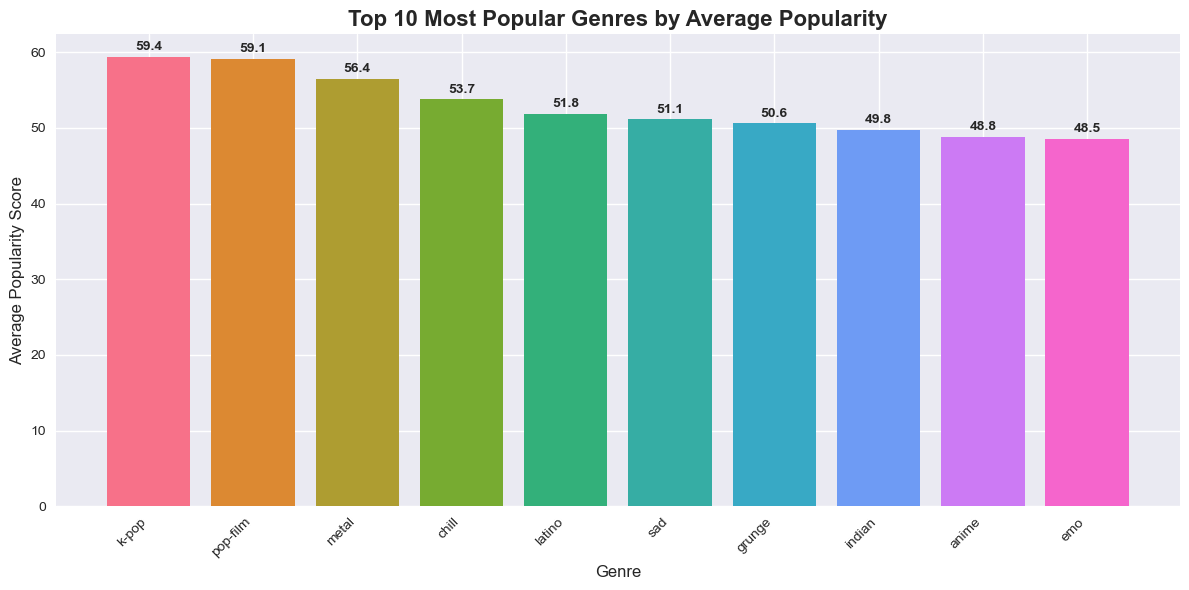

Chart 1 saved!


In [3]:
# Chart 1: Top 10 Most Popular Genres
plt.figure(figsize=(12, 6))

genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)

bars = plt.bar(genre_popularity.index, genre_popularity.values, color=sns.color_palette("husl", 10))

plt.title('Top 10 Most Popular Genres by Average Popularity', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Popularity Score', fontsize=12)
plt.xticks(rotation=45, ha='right')

# show value on each bar
for bar, value in zip(bars, genre_popularity.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_genre_popularity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

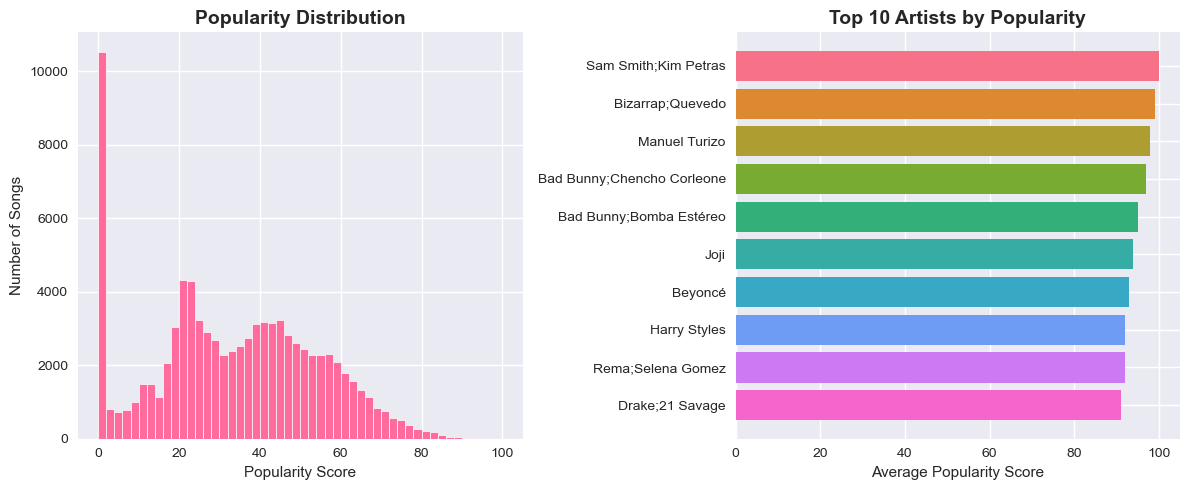

Chart 2 saved!


In [4]:
# Chart 2: Popularity Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['popularity'], bins=50, color='#FF6B9D', edgecolor='white', linewidth=0.5)
plt.title('Popularity Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Songs')

plt.subplot(1, 2, 2)
# Top 10 artists by average popularity
top_artists = df.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)
plt.barh(top_artists.index, top_artists.values, color=sns.color_palette("husl", 10))
plt.title('Top 10 Artists by Popularity', fontsize=14, fontweight='bold')
plt.xlabel('Average Popularity Score')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('chart2_popularity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

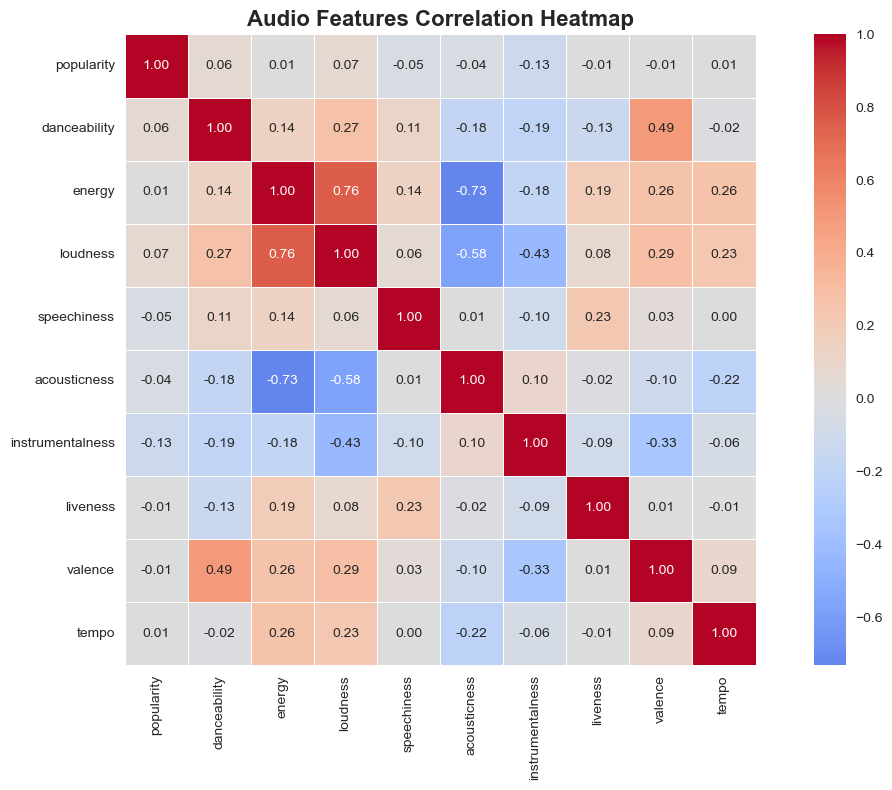

Chart 3 saved!


In [5]:
# Chart 3: Audio Features Correlation Heatmap
plt.figure(figsize=(12, 8))

# take only numerical audio features 
audio_features = ['popularity', 'danceability', 'energy', 'loudness', 
                  'speechiness', 'acousticness', 'instrumentalness', 
                  'liveness', 'valence', 'tempo']

correlation = df[audio_features].corr()

sns.heatmap(correlation, 
            annot=True,          # show numbers
            fmt='.2f',           # 2 decimal places
            cmap='coolwarm',     # red-blue color scheme
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Audio Features Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

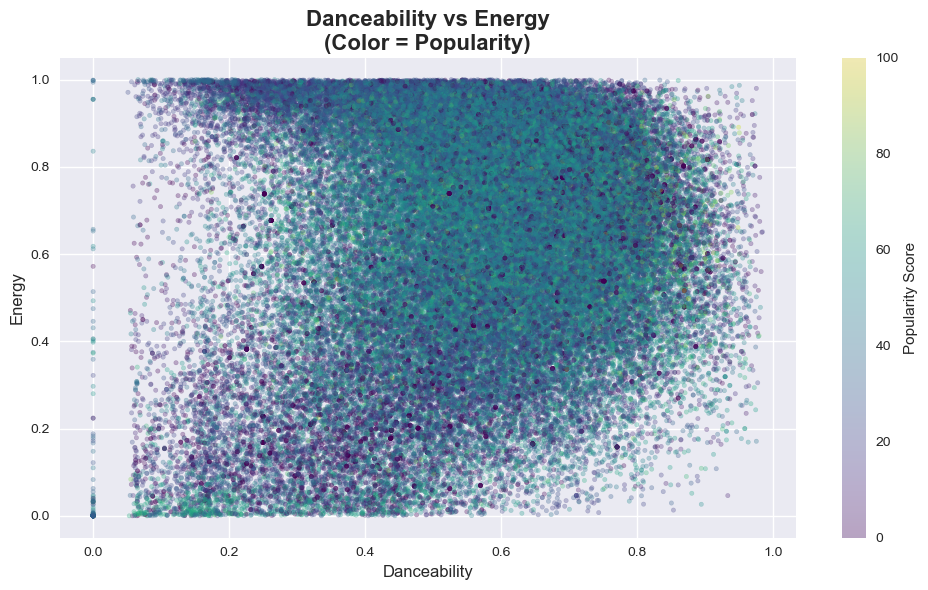

Chart 4 saved!


In [6]:
# Chart 4: Danceability vs Energy Scatter Plot
plt.figure(figsize=(10, 6))

scatter = plt.scatter(df['danceability'], 
                      df['energy'],
                      c=df['popularity'],
                      cmap='viridis',
                      alpha=0.3,
                      s=10)

plt.colorbar(scatter, label='Popularity Score')
plt.title('Danceability vs Energy\n(Color = Popularity)', fontsize=16, fontweight='bold')
plt.xlabel('Danceability', fontsize=12)
plt.ylabel('Energy', fontsize=12)

plt.tight_layout()
plt.savefig('chart4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

C:\Users\vidisha bhat\AppData\Local\Temp\ipykernel_31000\2076316710.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top,


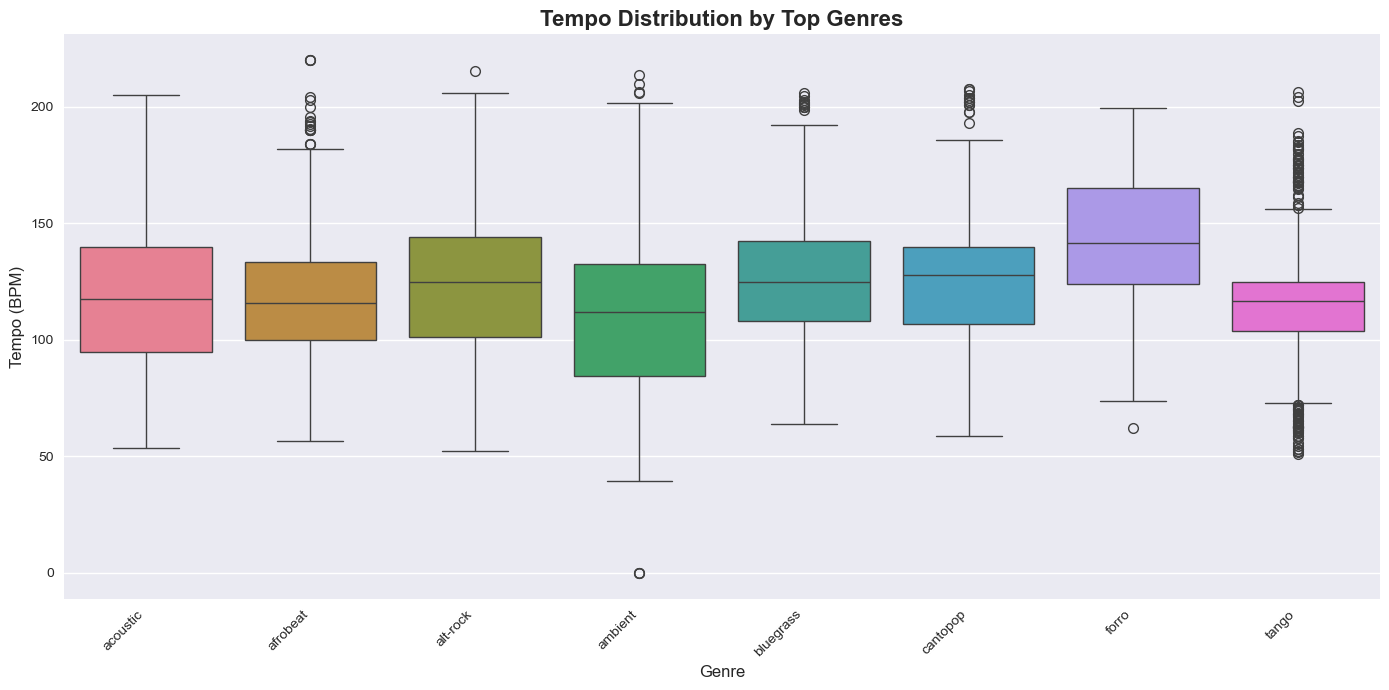

Chart 5 saved!

All 5 charts completed! EDA Done!


In [8]:
# Chart 5: Tempo Distribution by Top Genres
plt.figure(figsize=(14, 7))

# Top 8 genres lo
top_genres = df['track_genre'].value_counts().head(8).index
df_top = df[df['track_genre'].isin(top_genres)]

sns.boxplot(data=df_top, 
            x='track_genre', 
            y='tempo',
            palette='husl')

plt.title('Tempo Distribution by Top Genres', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Tempo (BPM)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('chart5_tempo_genres.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")
print("\nAll 5 charts completed! EDA Done!")